In [1]:
import pandas as pd

df_http = pd.read_json("metrics(http).json", lines=True)
df_https = pd.read_json("metrics(https).json", lines=True)
df_https

,type,data,metric
0,Metric,"{'name': 'http_reqs', 'type': 'counter', 'cont...",http_reqs
1,Point,"{'time': '2026-04-05T12:13:25.6501489+02:00', ...",http_reqs
2,Metric,"{'name': 'http_req_duration', 'type': 'trend',...",http_req_duration
3,Point,"{'time': '2026-04-05T12:13:25.6501489+02:00', ...",http_req_duration
4,Metric,"{'name': 'http_req_blocked', 'type': 'trend', ...",http_req_blocked
...,...,...,...
338619,Point,"{'time': '2026-04-05T12:15:40.9004694+02:00', ...",checks
338620,Point,"{'time': '2026-04-05T12:15:40.9004694+02:00', ...",data_sent
338621,Point,"{'time': '2026-04-05T12:15:40.9004694+02:00', ...",data_received
338622,Point,"{'time': '2026-04-05T12:15:40.9004694+02:00', ...",iteration_duration


In [2]:
df_https.columns

Index(['type', 'data', 'metric'], dtype='object')

In [3]:
https_points = df_https[df_https["type"] == "Point"].copy()
http_points = df_http[df_http["type"] == "Point"].copy()


In [4]:
expanded_http = pd.json_normalize(http_points["data"])
expanded_https = pd.json_normalize(https_points["data"])

In [5]:
expanded_http["metric"] = http_points["metric"].values
expanded_https["metric"] = https_points["metric"].values

In [6]:
expanded_https


,time,value,tags.expected_response,tags.group,tags.method,tags.name,tags.proto,tags.protocol,tags.scenario,tags.status,tags.test,tags.url,tags.check,tags.error,tags.error_code,metric
0,2026-04-05T12:13:25.6501489+02:00,1.0000,true,,GET,http://localhost:8088/auth/benchmark/ping,HTTP/1.1,http,stress,200,transport_ping,http://localhost:8088/auth/benchmark/ping,NaN,NaN,NaN,http_reqs
1,2026-04-05T12:13:25.6501489+02:00,202.3676,true,,GET,http://localhost:8088/auth/benchmark/ping,HTTP/1.1,http,stress,200,transport_ping,http://localhost:8088/auth/benchmark/ping,NaN,NaN,NaN,http_req_duration
2,2026-04-05T12:13:25.6501489+02:00,2.6615,true,,GET,http://localhost:8088/auth/benchmark/ping,HTTP/1.1,http,stress,200,transport_ping,http://localhost:8088/auth/benchmark/ping,NaN,NaN,NaN,http_req_blocked
3,2026-04-05T12:13:25.6501489+02:00,0.6567,true,,GET,http://localhost:8088/auth/benchmark/ping,HTTP/1.1,http,stress,200,transport_ping,http://localhost:8088/auth/benchmark/ping,NaN,NaN,NaN,http_req_connecting
4,2026-04-05T12:13:25.6501489+02:00,0.0000,true,,GET,http://localhost:8088/auth/benchmark/ping,HTTP/1.1,http,stress,200,transport_ping,http://localhost:8088/auth/benchmark/ping,NaN,NaN,NaN,http_req_tls_handshaking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338603,2026-04-05T12:15:40.9004694+02:00,1.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,is status 200,NaN,NaN,checks
338604,2026-04-05T12:15:40.9004694+02:00,89.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,NaN,NaN,NaN,data_sent
338605,2026-04-05T12:15:40.9004694+02:00,177.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,NaN,NaN,NaN,data_received
338606,2026-04-05T12:15:40.9004694+02:00,20270.7497,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,NaN,NaN,NaN,iteration_duration


In [7]:
http_df = expanded_http[expanded_http["metric"] == "http_req_duration"].copy()
https_df = expanded_https[expanded_https["metric"] == "http_req_duration"].copy()

In [8]:
https_df["value"].max

<bound method Series.max of 1           202.3676
15            3.6231
29            2.9668
43            2.2379
57           14.4853
             ...    
338539    20204.2014
338553    20205.8292
338567    20285.9227
338581    20280.4706
338595    20261.6753
Name: value, Length: 24167, dtype: float64>

In [9]:
https_df = https_df.dropna(axis=1, how="all").copy()
http_df = http_df.dropna(axis=1, how="all").copy()

In [10]:
http_df["time"] = pd.to_datetime(http_df["time"])
http_df = http_df.sort_values("time")

https_df["time"] = pd.to_datetime(https_df["time"])
https_df = https_df.sort_values("time")

# Convert to seconds relative to first timestamp
http_df["time_sec"] = (http_df["time"] - http_df["time"].min()).dt.total_seconds()
https_df["time_sec"] = (https_df["time"] - https_df["time"].min()).dt.total_seconds()

In [11]:
https_df["time_sec"]

1           0.000000
15          0.005191
29          0.008157
43          0.010395
57          0.025637
             ...    
338497    135.245987
338483    135.245987
338511    135.245987
338581    135.250320
338595    135.250320
Name: time_sec, Length: 24167, dtype: float64

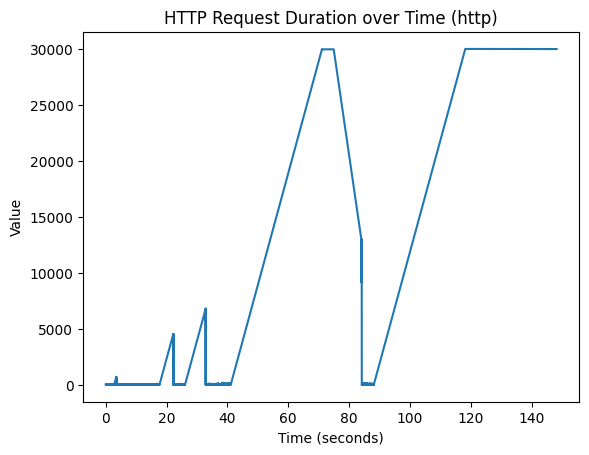

In [24]:
import matplotlib.pyplot as plt

plt.plot(http_df[http_df["tags.test"] == "transport_ping"].time_sec, http_df[http_df["tags.test"] == "transport_ping"].value, label="https")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (http)")
plt.show()

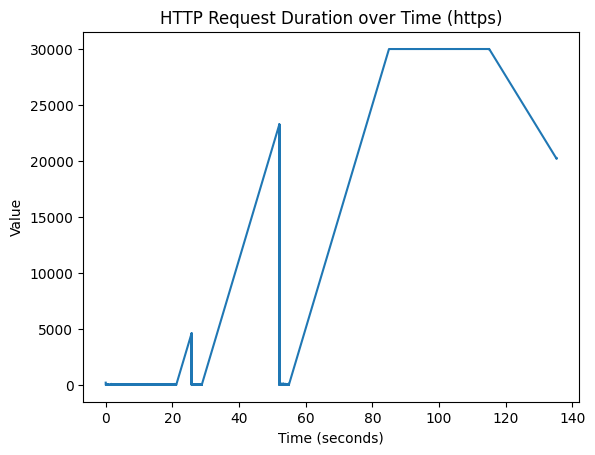

In [25]:
plt.plot(https_df[https_df["tags.test"] == "transport_ping"].time_sec, https_df[https_df["tags.test"] == "transport_ping"].value, label="https")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (https)")
plt.show()

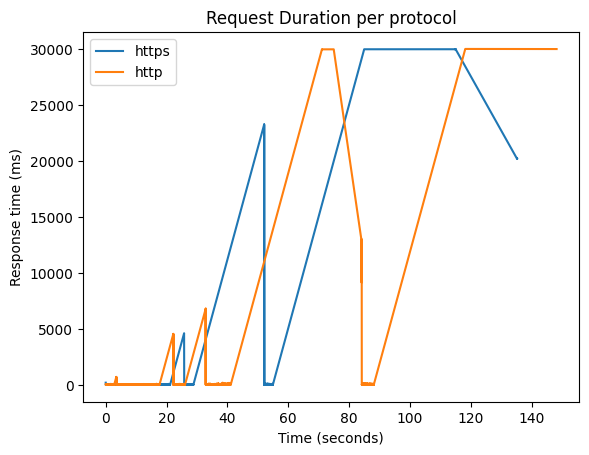

In [21]:
plt.plot(https_df[https_df["tags.test"] == "transport_ping"].time_sec, https_df[https_df["tags.test"] == "transport_ping"].value, label="https")
plt.plot(http_df[http_df["tags.test"] == "transport_ping"].time_sec, http_df[http_df["tags.test"] == "transport_ping"].value, label="http")
plt.xlabel("Time (seconds)")
plt.ylabel("Response time (ms)")
plt.legend()
plt.title("Request Duration per protocol")
plt.show()